In [1]:
import pandas as pd
import numpy as np
import matplotlib as pyplot
import seaborn as sns

In [2]:
fake=pd.read_csv("C:/Users/Ashwini/OneDrive/Desktop/FakeNewsDetection/Fake.csv")
real=pd.read_csv("C:/Users/Ashwini/OneDrive/Desktop/FakeNewsDetection/True.csv")

In [3]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [7]:
fake["label"]=0
real["label"]=1

In [9]:
data=pd.concat([fake, real])

In [11]:
data=data.sample(frac=1)

In [13]:
data

,title,text,subject,date,label
17391,Philippine military chief says 'matter of days...,MANILA (Reuters) - The Philippine military wil...,worldnews,"October 16, 2017",1
3395,Bloomberg delivers U.S. pledge to continue Par...,WASHINGTON (Reuters) - Former New York City Ma...,politicsNews,"June 5, 2017",1
6419,George Zimmerman Is Selling The Gun He Used T...,"***UPDATE***The listing has been removed, and ...",News,"May 12, 2016",0
2282,WATCH: Former Director Of National Intelligen...,Donald Trump has absolutely no evidence that P...,News,"March 5, 2017",0
6889,Factbox: Contenders for key jobs in Trump's ad...,(Reuters) - Below are people mentioned as cont...,politicsNews,"December 6, 2016",1
...,...,...,...,...,...
21238,Thousands more Rohingya flee to border as Myan...,"COX S BAZAR, Bangladesh (Reuters) - More than ...",worldnews,"August 30, 2017",1
9837,Former Army Ranger is Only Steelers Player Who...,Former Army Ranger Alejandro Villanueva was th...,politics,"Sep 24, 2017",0
1788,Trump open to Dreamers relief legislation with...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"September 21, 2017",1
17461,BARBRA STREISAND Gives Up On Dream Of Impeachi...,Barbra Streisand was an Obama sycophant and on...,left-news,"Dec 31, 2017",0


In [15]:
data.shape

(44898, 5)

In [17]:
data.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [19]:
data=data[['text','label']]
data.head()

,text,label
17391,MANILA (Reuters) - The Philippine military wil...,1
3395,WASHINGTON (Reuters) - Former New York City Ma...,1
6419,"***UPDATE***The listing has been removed, and ...",0
2282,Donald Trump has absolutely no evidence that P...,0
6889,(Reuters) - Below are people mentioned as cont...,1


In [21]:
import re

In [23]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

In [25]:
data.loc[:, 'text'] = data['text'].apply(clean_text)

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(data['text'])
y = data['label']

In [27]:
vectorizer

TfidfVectorizer(stop_words='english')

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [30]:
predictions = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9880846325167038


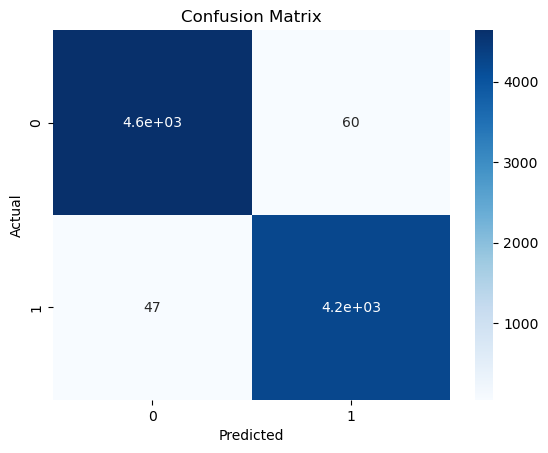

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [33]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

In [61]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_predictions = nb_model.predict(X_test)

In [62]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score
lr_accuracy = accuracy_score(y_test, lr_predictions)
nb_accuracy = accuracy_score(y_test, nb_predictions)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Logistic Regression Accuracy:", lr_accuracy)
print("Naive Bayes Accuracy:", nb_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.9880846325167038
Naive Bayes Accuracy: 0.9437639198218263
Random Forest Accuracy: 0.9899777282850779


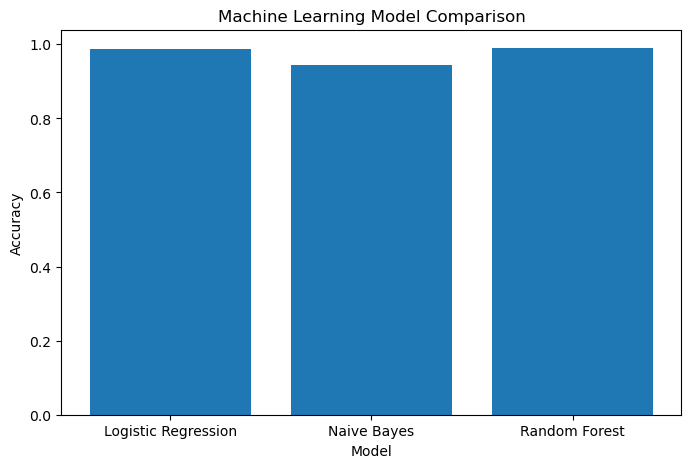

In [81]:
models = ['Logistic Regression', 'Naive Bayes', 'Random Forest']
scores = [lr_accuracy, nb_accuracy, rf_accuracy]
plt.figure(figsize=(8,5))
plt.bar(models, scores)
plt.title("Machine Learning Model Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.show()

### Problem Statement

The goal of this project is to build a machine learning ,odels that can automatically classify news articles as fake or real using natural language processing techniques.

### Dataset:
This project uses the Fake and Real News Dataset from Kaggle.
The dataset contains approximately 44,000 news articles labeled as fake or real.

### Methodology:
1. Data preprocessing and text cleaning
2. TF-IDF vectorization for feature extraction
3. Training machine learning models
4. Model evaluation using accuracy and confusion matrix

### Conclusion:
The Random Forest and Logistic Regression models achieved the highest accuracy (~98.8%) for fake news classification using TF-IDF features.
This demonstrates that machine learning can effectively detect misinformation in news articles.